# Nullstellen

## Übungen - Lösungen


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1: Unterschiede zwischen Bisektionsverfahren und Newtonverfahren

Beschreibe und bewerte qualitativ die unterschiedlichen Eigenschaften des Bisektionsverfahrens und des Newtonverfahrens. In welchen Situationen ist welches Verfahren besser geeignet?

**Lösung:** (nicht abschliessend)

<!-- - Newton:
    - Schnelle Konvergenz (+)
    - Nicht leicht vorherzusehen, welche Nullstelle gefunden wird, wenn es mehrere gibt (-)
    - Ableitung f'(x) muss bekannt sein (-) [allerdings kann diese auch numerisch geschätzt werden]
    - Nullstellen in der Ableitung (lokale Extrema oder Sattelpunkte) können Probleme verursachen.
    - Fehler in x-Richtung nicht so gut schätzbar (-)

- Bisektion:
    - Langsame Konvergenz (-)
    - Start-Intervall grenzt die gesuchte Nullstelle bereits ein, auch wenn es mehrere NS gibt (+)
    - Ableitung muss nicht bekannt sein (+)
    - Nullstellen der Ableitung bereiten keine Probleme (+)
    - Fehler in x-Richtung ist gut unter Kontrolle (+) -->

| Eigenschaft               | Bisektionsverfahren     | Newton-Verfahren          |
|---------------------------|-------------------------|---------------------------|
| Startwert                 | Intervall               | Schätzung                 |
| Konvergenz                | (-) langsam             | (+) schnell               |
| analytische Ableitung     | (+) nicht nötig         | (-) nötig                 |
| Nullstellen der Ableitung | (+) kein Problem        | (-) kann ein Problem sein |
| Fehler in x-Richtung      | (+) einfach zu schätzen | (-) schwer zu schätzen    |
| Fehler in y-Richtung      | einfach zu schätzen     | einfach zu schätzen       |

### Aufgabe 2: Nullstellen einer Funktion

#### a) Darstellung

Wir betrachten folgende Funktion, die Nullstellen bei $x=-1$, $3$ und $4$ hat:

$$ f(x) = x^3 - 6x^2 + 5x + 12 $$

- Berechne die Ableitung von Hand und definiere $f(x)$ und $f'(x)$ als Python Funktionen `f(x)` und `fprime(x)`. 
- Stelle beide Funktionen im Bereich $x \in \left[-2,5\right]$ dar und markiere die Nullstellen von $f(x)$.

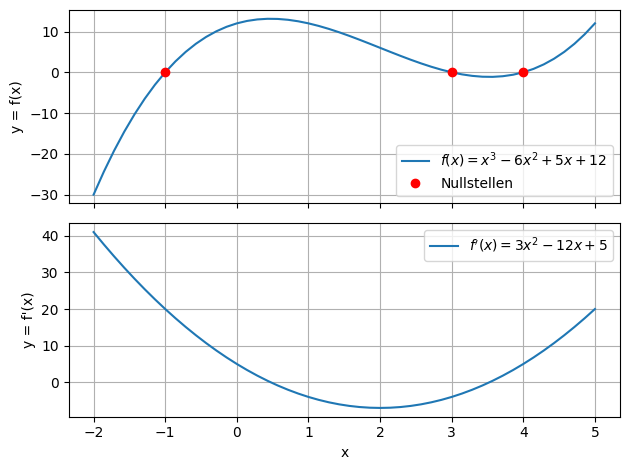

In [2]:
def f(x):
    return x**3 - 6 * x**2 + 5 * x + 12


def fprime(x):
    return 3 * x**2 - 12 * x + 5


x_roots = np.array([-1, 3, 4])
x = np.linspace(-2, 5)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(x, f(x), label=r"$f(x) = x^3 - 6x^2 + 5x + 12$")
ax1.plot(x_roots, np.zeros_like(x_roots), "ro", label="Nullstellen")
ax1.set_ylabel("y = f(x)")
ax1.legend()
ax1.grid()
ax2.plot(x, fprime(x), label=r"$f'(x) = 3x^2 - 12x + 5$")
ax2.set_xlabel("x")
ax2.set_ylabel("y = f'(x)")
ax2.legend()
ax2.grid()
plt.tight_layout()
plt.show()

#### b) Nullstellen bestimmen mit SciPy

Wie gesagt hat die Funktion 3 Nullstellen in diesem Bereich.

- Benutze die Funktion [`scipy.optimize.newton`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html), um eine der Nullstellen zu berechnen. Gebe der SciPy Funktion `f`, den Startwert `x0=0` und die Ableitung `fprime` mit.
- Probiere auch mal [`scipy.optimize.root_scalar`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html) aus.
- Benutze auch die Implementierungen des Newton-Verfahrens und des Bisektionsverfahrens aus der Vertiefung, um die Nullstellen zu berechnen. Vergleiche die Ergebnisse.

Welche der Nullstellen wurde gefunden? Welches Verfahren konvergiert schneller?

In [3]:
from scipy import optimize

x0 = 0
optimize.newton(f, x0, fprime)

np.float64(-1.0)

In [4]:
optimize.root_scalar(f, x0=x0, fprime=fprime)

      converged: True
           flag: converged
 function_calls: 14
     iterations: 7
           root: -1.0
         method: newton

In [5]:
def newton(f, fprime, x0, xtol, ytol, maxiter):
    """Newton-Verfahren aus der Vertiefung"""
    assert xtol > 0
    assert ytol > 0
    assert maxiter >= 0

    x = x0
    y = f(x)
    y_by_yprime = y / fprime(x)
    Dy = abs(y)
    Dx = abs(y_by_yprime)
    steps = 0
    res = [(steps, x, Dx, Dy)]

    while (Dx > xtol or Dy > ytol) and steps < maxiter:
        x = x - y_by_yprime
        y = f(x)
        y_by_yprime = y / fprime(x)
        Dy = abs(y)
        Dx = abs(y_by_yprime)
        steps += 1
        res.append((steps, x, Dx, Dy))

    return np.array(res)

In [6]:
def bisection(f, a0, b0, xtol, ytol, maxiter):
    """Bisektionsverfahren aus der Vertiefung"""
    assert a0 < b0
    assert f(a0) * f(b0) < 0
    assert xtol > 0
    assert ytol > 0
    assert maxiter >= 0

    a, b = a0, b0
    x = (a + b) / 2
    y = f(x)
    ya = f(a)
    Dx = abs(b - a) / 2
    Dy = abs(y)
    steps = 0
    res = [(steps, x, Dx, Dy)]

    while (Dx > xtol or Dy > ytol) and steps < maxiter:
        if ya * y < 0:
            b = x
        else:
            a = x
            ya = y
        x = (a + b) / 2
        y = f(x)
        Dx = abs(b - a) / 2
        Dy = abs(y)
        steps += 1
        res.append((steps, x, Dx, Dy))

    return np.array(res)

In [7]:
print(newton(f, fprime, x0, 1e-8, 1e-8, 100)[-1])
print(bisection(f, -2, 5, 1e-8, 1e-8, 100)[-1])

[ 6.00000000e+00 -1.00000000e+00  1.90709670e-12  3.81419341e-11]
[ 3.20000000e+01 -1.00000000e+00  8.14907253e-10  2.32830644e-09]


#### c) Mehrere Startwerte für Newton-Verfahren

Die Funktion [`scipy.optimize.newton`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html) kann auch mit einem Array aus mehreren Startwerten arbeiten. Ausgehend von jedem dieser Startwerte wird eine Nullstelle gesucht. Probiere es aus, indem Du ein paar Startwerte zusammenpackst.

In [8]:
x0 = np.array([-2, 0, 5])
optimize.newton(f, x0, fprime)

array([-1., -1.,  4.])

#### d) Mehrere Nullstellen mit zufälligen Startwerten finden.

Nun sollen die Startwerte zufällig ausgewählt werden.

**1.** Schreibe eine Funktion, die für eine gegebene Anzahl Versuche alle Nullstellen einer Funktion finden soll. Die Startwerte sollen innerhalb eines definierten Intervalls liegen und aus diesem zufällig gewählt werden.

Verwende für das finden von den Nullstellen die SciPy Funktion [scipy.optimize.newton](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html).

Funktion `root_finding(f, fprime, low, high, trials, seed=1)`:

- `f`: Funktion, deren Nullstellen gesucht werden sollen
- `fprime`: Die Ableitung von `f`
- `low`: untere Intervallsgrenze
- `high`: obere Intervallsgrenze
- `trials`: Anzahl Versuche, Nullstellen zu finden
- `seed=123456`: Seed des Zufallszahlengenerators mit Default 123456

Die Funktion soll ein Array zurückliefern, wobei in der ersten Spalte die zufälligen Startwerte und in der zweiten Spalte die zugehörigen Nullstellen stehen.

In [9]:
def root_finding(f, fprime, low, high, trials, seed=123456):
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(low, high, size=trials)
    x = optimize.newton(f, x0, fprime)
    return np.array([x0, x]).T

**2.** Teste `root_finding` mit der Funktion $f(x)$ aus Teil a) und 3 Startwerten im Intervall $[-2, 5]$.

Du solltest die Nullstellen 3, 4 und -1 finden, wenn du den Seed bei 123456 belässt.

In [10]:
root_finding(f, fprime, -2, 5, 3)

array([[ 2.45559625,  3.        ],
       [ 0.69368165,  4.        ],
       [-1.66788205, -1.        ]])

Wenn du wesentlich mehr Startwerte erzeugst, findest Du natürlich immer wieder die gleichen Nullstellen. Teste dies mit 25 Startwerten oder mehr.

In [11]:
root_finding(f, fprime, -2, 5, 25)

array([[ 2.45559625,  3.        ],
       [ 0.69368165,  4.        ],
       [-1.66788205, -1.        ],
       [ 4.68676918,  4.        ],
       [ 4.34235656,  4.        ],
       [ 1.19878688,  3.        ],
       [-0.03626567, -1.        ],
       [ 2.45304162,  3.        ],
       [ 4.86497483,  4.        ],
       [ 3.6870225 ,  4.        ],
       [ 0.13638771, -1.        ],
       [ 1.9760767 ,  3.        ],
       [-1.85518979, -1.        ],
       [ 2.01170345,  3.        ],
       [ 0.88533942,  4.        ],
       [ 0.41701228, -1.        ],
       [ 3.11316375,  3.        ],
       [-0.02789082, -1.        ],
       [-1.84365879, -1.        ],
       [-0.24095231, -1.        ],
       [-0.32567949, -1.        ],
       [ 2.3339966 ,  3.        ],
       [ 3.51358924, -1.        ],
       [ 0.01176857, -1.        ],
       [ 0.44244442, -1.        ]])

#### e) Nur unterschiedliche Nullstellen finden

**1.** Benutze `root_finding` aus Teil c), um nur unterschiedliche Nullstellen zu finden.

- Schreibe dazu eine neue Funktion `root_finding_unique`, welche `root_finding` benutzt.
- Die Funktion soll nur noch die Nullstellen als Array liefern und nicht mehr die Startwerte.
- Es sollten jetzt keine doppelten Einträge mehr vorkommen. Nutze dazu [`np.unique`](https://numpy.org/doc/stable/reference/generated/numpy.unique.html).


In [12]:
def root_finding_unique(f, fprime, low, high, trials, seed=1):
    _, x = root_finding(f, fprime, low, high, trials, seed).T
    return np.unique(x)

**2.** Teste `root_finding_unique` mit der Funktion $f(x)$ und zuerst 5 und dann 50 Startwerten im Intervall $[-2, 5]$.

Benutze weiterhin den Seed 123456, um vergleichbare Ergebnisse zu erhalten.

In [13]:
root_finding_unique(f, fprime, -2, 5, 5)

array([-1.,  3.,  4.])

In [14]:
root_finding_unique(f, fprime, -2, 5, 50)

array([-1.,  3.,  3.,  3.,  3.,  4.])

In [15]:
for x in root_finding_unique(f, fprime, -2, 5, 50):
    print(x)

-1.0
2.999999999999998
2.9999999999999987
3.0
3.000000000000001
4.0


Warum haben wir im Fall `trials=50` trotzdem am Ende noch vier Mal (beinahe) die 3 in der Lösung?

**Lösung:** Die Funktion [`np.unique`](https://numpy.org/doc/stable/reference/generated/numpy.unique.html) entfern nur doppelte Einträge, wenn sie innerhalb der Maschinenpräzision gleich sind. Da die Nullstellen numerisch bestimmt werden, können die Ergebnisse innerhalb der Toleranz des Newton-Verfahrens leicht variieren. Die Tolernaz ist normalerweise grösser als die Maschinenpräzision.

### Aufgabe 3: Nullstellen von Daten

#### a) Daten importieren

In der Datei `weight.csv` sind Gewichtsmessungen an verschiedenen Tagen zu finden. Die erste Spalte gibt das Datum, die zweite die Anzahl Tage seit der ersten Messung und die dritte das gemessehe Gewicht in kg an.

- Importiere die zweite und dritte Spalte der Datei `weight.csv` in zwei 1D-Arrays namens `day` und `weight`.
- Bestimme wie viele Messerte es gibt und in welchem Zeitraum (Anzahl Tage) die Messungen gemacht wurden.

In [16]:
day, weight = np.loadtxt("weight.csv", delimiter=";", usecols=(1, 2), skiprows=1).T

len(day), float(day.min()), float(day.max())

# Es gibt 76 Messwerte, die von Tag 0 bis Tag 96 reichen.
# Also gibt es nicht an jedem Tag einen Messwert. => fehlende Werte.

(76, 0.0, 96.0)

#### b) Daten interpolieren

- Bestimme mithilfe von SciPy eine kubische Spline-Interpolationsfunktion der Gewichtsdaten mit natürlichen Randbedingungen. Nenne sie `w_spline`.
- Stelle die Interpolationsfunktion zusammen mit den Daten dar.
  - Dazu musste du zuerst die Interpolationsfunktion an vielen Punkten im Bereich der Daten auswerten, z.B. n=1000 Punkte.
  - Stelle die Interpolationsfunktion als durchgezogene Linie und die Daten als kleine Punkte dar.
  - Füge Achsenbeschriftungen, Legende und ein Gitternetz hinzu.

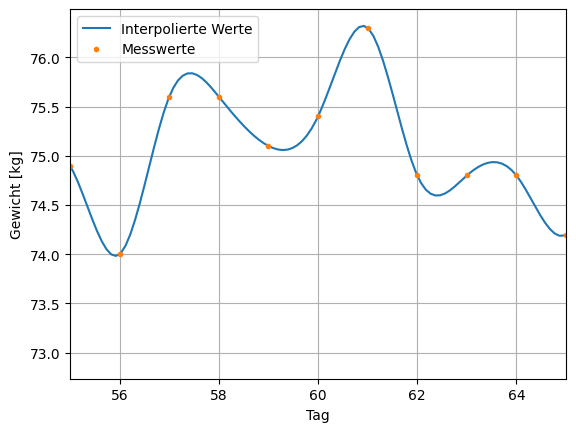

In [17]:
from scipy.interpolate import make_interp_spline

w_spline = make_interp_spline(day, weight, k=3, bc_type="natural")
t = np.linspace(day.min(), day.max(), 1000)
w = w_spline(t)

plt.plot(t, w, label="Interpolierte Werte")
plt.plot(day, weight, ".", label="Messwerte")
plt.xlabel("Tag")
plt.ylabel("Gewicht [kg]")
plt.grid()
plt.legend()
plt.xlim(55, 65)
plt.show()

#### c) Schnittpunkte bestimmen

Im Diagramm aus Teil b) wird ersichtlich, dass das Gewicht zwischen den Tagen 55 und 65 ingesamt vier Mal den Schwellenwert 75.5 kg kreuzt.

Das Ziel ist es, die Zeitpunkte dieser vier Schnittpunkte zu bestimmen. Dazu müssen die Nullstellen der Differenz `w_spline(x) - 75.5` gefunden werden.

- Definiere eine Funktion `f(x)`, welche diese Differenz berechnet.
- Schätze dazu von Auge gute Startwerte bzw. Startintervalle für das Newton- bzw. Bisektionsverfahren.
- Finde alle vier Nullstellen.

Tipp: Folgende Funktionen kannst du für diese Aufgabe benutzen:

- [`scipy.optimize.bisect`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.bisect.html)
- [`scipy.optimize.newton`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html).
- [`scipy.optimize.root_scalar`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html)

Bemerkung: Die Funktion [`scipy.optimize.newton`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html) kann auch verwendet werden, wenn die Ableitung `fprime` nicht bekannt ist. In diesem Fall wird die Sekantenmethode verwendet, eine leicht angepasste Variante des Newton-Verfahrens, bei dem die Ableitung auch numerisch bestimmt wird.

In [18]:
threshold = 75.5


def f(x):
    return w_spline(x) - threshold


roots = [
    optimize.bisect(f, 56, 57.5),
    optimize.bisect(f, 57.5, 59),
    optimize.newton(f, 60),
    optimize.newton(f, 61.5),
]

print("Die vier Nullstellen befinden sich bei:")
np.array(roots)

Die vier Nullstellen befinden sich bei:


array([56.92735956, 58.16201008, 60.0867981 , 61.57252364])

#### d) Schnittpunkte darstellen

- Plotte die Nullstellen im Diagramm mit den interpolierten und gemessenen Daten.
- Stelle die Nullstellen als rote Kreuze dar.

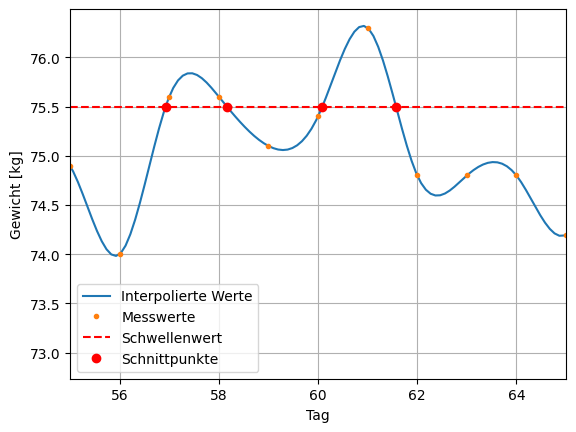

In [19]:
plt.plot(t, w, label="Interpolierte Werte")
plt.plot(day, weight, ".", label="Messwerte")
plt.axhline(threshold, color="red", linestyle="--", label="Schwellenwert")
plt.plot(roots, np.full_like(roots, threshold), "ro", label="Schnittpunkte")
plt.xlabel("Tag")
plt.ylabel("Gewicht [kg]")
plt.grid()
plt.legend()
plt.xlim(55, 65)
plt.show()